In [ ]:
#only loss graph is only needed to be plotted, accuracy graph is not needed. So, I have removed the code for plotting accuracy graph and kept only the code for plotting loss graph.

In [ ]:
import numpy as np
import pandas as pd 
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout, Embedding
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split


In [ ]:
#sample dataset
corpus = [
    "I love machine learning",
    "LSTM networks are powerful for sequence data",
    "RNNs can capture temporal dependencies",
    "Deep learning is revolutionizing AI",
    "Natural language processing is fascinating",
    "I enjoy coding in Python",
    "Neural networks can approximate complex functions",
    "Recurrent layers help with time series data",
    "Natural language processing is a key area of AI",
    "I am excited about deep learning advancements",
    "Deep learning models require large datasets",
    "AI is transforming various industries",
    "Sequence models are essential for NLP tasks",
    "LSTM can handle long-term dependencies",
    "RNNs are prone to vanishing gradients",
    "Embedding layers help with word representations",
    "Dropout is a regularization technique",
    "Adam optimizer is widely used for training deep learning models",
    "TensorFlow and PyTorch are popular deep learning frameworks",
    "Data preprocessing is crucial for model performance",

]

#Tokenize the text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1 #+1 added to accommodate for padding token
print("Total unique words:", total_words)
    
#create input sequence and labels
input_sequences = []
for line in corpus:
    token_list = tokenizer.texts_to_sequences([line])[0] #convert the input text to a sequence of integers
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        print("n-gram sequence:", n_gram_sequence)
        input_sequences.append(n_gram_sequence)

print("Total input sequences:", len(input_sequences))

#pad sequences
max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')
print("Padded input sequences:\n", input_sequences)


Total unique words: 84
n-gram sequence: [6, 23]
n-gram sequence: [6, 23, 24]
n-gram sequence: [6, 23, 24, 2]
n-gram sequence: [11, 12]
n-gram sequence: [11, 12, 4]
n-gram sequence: [11, 12, 4, 25]
n-gram sequence: [11, 12, 4, 25, 5]
n-gram sequence: [11, 12, 4, 25, 5, 13]
n-gram sequence: [11, 12, 4, 25, 5, 13, 7]
n-gram sequence: [14, 8]
n-gram sequence: [14, 8, 26]
n-gram sequence: [14, 8, 26, 27]
n-gram sequence: [14, 8, 26, 27, 15]
n-gram sequence: [3, 2]
n-gram sequence: [3, 2, 1]
n-gram sequence: [3, 2, 1, 28]
n-gram sequence: [3, 2, 1, 28, 9]
n-gram sequence: [16, 17]
n-gram sequence: [16, 17, 18]
n-gram sequence: [16, 17, 18, 1]
n-gram sequence: [16, 17, 18, 1, 29]
n-gram sequence: [6, 30]
n-gram sequence: [6, 30, 31]
n-gram sequence: [6, 30, 31, 32]
n-gram sequence: [6, 30, 31, 32, 33]
n-gram sequence: [34, 12]
n-gram sequence: [34, 12, 8]
n-gram sequence: [34, 12, 8, 35]
n-gram sequence: [34, 12, 8, 35, 36]
n-gram sequence: [34, 12, 8, 35, 36, 37]
n-gram sequence: [38, 19]
n-

In [ ]:
x = input_sequences[:, :-1]
y = input_sequences[:, -1]
y = tf.keras.utils.to_categorical(y, num_classes=total_words)
max_len = x.shape[1] + 1

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

In [ ]:
model=Sequential()
model.add(Embedding(total_words, 100, input_length=max_len-1))
model.add(LSTM(32))
model.add(Dropout(0.5))
model.add(Dense(total_words, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_9 (Embedding)     (None, 9, 100)            8400      
                                                                 
 lstm_9 (LSTM)               (None, 32)                17024     
                                                                 
 dropout_9 (Dropout)         (None, 32)                0         
                                                                 
 dense_9 (Dense)             (None, 84)                2772      
                                                                 
Total params: 28196 (110.14 KB)
Trainable params: 28196 (110.14 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
history=model.fit(X_train, y_train, epochs=350, batch_size=8, validation_data=(X_test, y_test), verbose=1)

Epoch 1/350
12/12 [==============================] - 0s 14ms/step - loss: 2.1736 - accuracy: 0.4737 - val_loss: 6.0205 - val_accuracy: 0.0000e+00
Epoch 2/350
12/12 [==============================] - 0s 8ms/step - loss: 2.2176 - accuracy: 0.4632 - val_loss: 5.9124 - val_accuracy: 0.0000e+00
Epoch 3/350
12/12 [==============================] - 0s 9ms/step - loss: 2.0836 - accuracy: 0.4632 - val_loss: 5.8805 - val_accuracy: 0.0000e+00
Epoch 4/350
12/12 [==============================] - 0s 9ms/step - loss: 2.0796 - accuracy: 0.4842 - val_loss: 5.9433 - val_accuracy: 0.0000e+00
Epoch 5/350
12/12 [==============================] - 0s 12ms/step - loss: 2.0524 - accuracy: 0.5684 - val_loss: 6.0614 - val_accuracy: 0.0000e+00
Epoch 6/350
12/12 [==============================] - 0s 11ms/step - loss: 1.9905 - accuracy: 0.6316 - val_loss: 6.1109 - val_accuracy: 0.0000e+00
Epoch 7/350
12/12 [==============================] - 0s 11ms/step - loss: 2.0761 - accuracy: 0.5368 - val_loss: 6.0532 - val_ac

In [ ]:
def predict_next_word(text):
    token_list = tokenizer.texts_to_sequences([text])[0]
    token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    return tokenizer.index_word[np.argmax(predicted)]

#Example usage
input_text = "learning"
predicted_word = predict_next_word(input_text)
print(f"Predicted next word:{predicted_word}")

Predicted next word:is


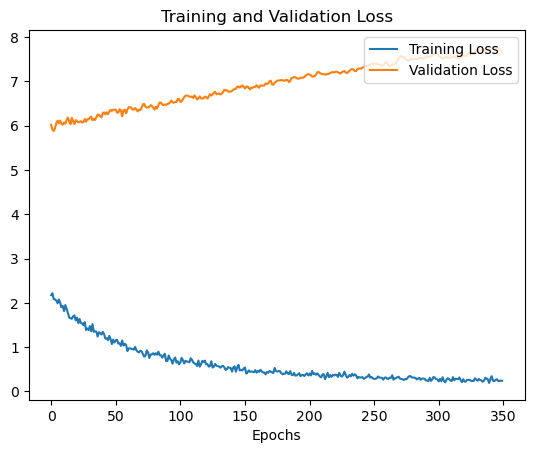

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.legend(loc = 'upper right')
plt.show()   
